In [ ]:
from datasets import load_dataset

from genaibook.core import show_images
import matplotlib as mpl

from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import torchsummary

import pandas as pd

In [ ]:


mnist = load_dataset("mnist")

mnist

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

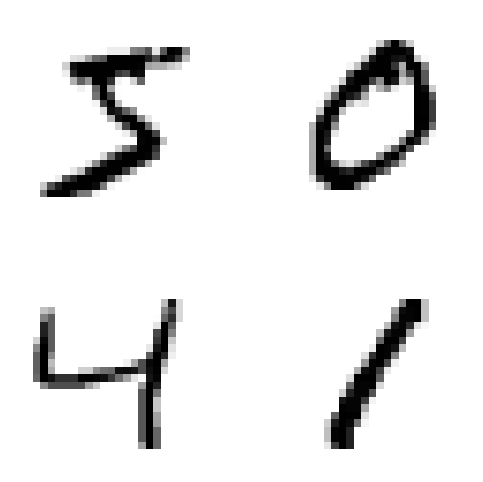

In [ ]:

mpl.rcParams["image.cmap"] = "gray_r"

show_images(mnist["train"]["image"][:4])

In [ ]:

def mnist_to_tensor(samples):
    t = transforms.ToTensor()
    samples["image"] = [t(image) for image in samples["image"]]
    return samples


mnist = mnist.with_transform(mnist_to_tensor)
mnist["train"] = mnist["train"].shuffle(seed=1337)

In [4]:
x = mnist["train"]["image"][0]
x.max(),x.min()

(tensor(1.), tensor(0.))

In [ ]:


bs = 64
train_dataloader = DataLoader(mnist["train"]["image"],batch_size = bs)

In [ ]:


def conv_block(in_channels,out_channels,kernel_size = 4,stride = 2,padding = 1):
    return nn.Sequential(
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding


        ),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
    )

In [7]:
class Encoder(nn.Module):

    #Hardcoded to produce latent dim of 16
    def __init__(self,in_channels):
        super().__init__()
        self.conv1 = conv_block(in_channels,128)
        self.conv2 = conv_block(128,256)
        self.conv3 = conv_block(256,512)
        self.conv4 = conv_block(512,1024)
        self.linear = nn.Linear(1024,16)

    def forward(self,x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.linear(x.flatten(start_dim=1))

        return x

In [8]:
in_channels = 1
x = mnist["train"]["image"][0][None, :]
encoder = Encoder(in_channels).eval()

encoded = encoder(x)
encoded.shape


torch.Size([1, 16])

In [9]:
batch = next(iter(train_dataloader))
encoded = Encoder(in_channels=1)(batch)

batch.shape, encoded.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64, 16]))

In [10]:
def conv_transpose_block(
    in_channels,
    out_channels,
    kernel_size=3,
    stride=2,
    padding=1,
    output_padding=0,
    with_act = True    
):
    modules = [
        nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size,
            stride,
            padding,
            output_padding
        )
    ]
    if with_act:
        modules.append(nn.BatchNorm2d(out_channels))
        modules.append(nn.ReLU())
    return nn.Sequential(*modules)


class Decoder(nn.Module):
    def __init__(self,out_channels):
        super().__init__()
        
        self.linear = nn.Linear(16,1024*4*4) #Takes the compressed 16 dim to 1024 channels 4x4 after reshape
        self.t_conv1 = conv_transpose_block(1024,512) 
        self.t_conv2 = conv_transpose_block(512,256,output_padding=1)
        self.t_conv3 = conv_transpose_block(256,out_channels,output_padding=1)

    def forward(self,x):
        bs = x.shape[0]
        x = self.linear(x)
        x = x.reshape((bs,1024,4,4))
        x = self.t_conv1(x)
        x = self.t_conv2(x)
        x = self.t_conv3(x)

        return x

In [11]:
decoded_batch = Decoder(x.shape[0])(encoded)
decoded_batch.shape

torch.Size([64, 1, 28, 28])

In [12]:
class AutoEncoder(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.encoder = Encoder(in_channels)
        self.decoder = Decoder(in_channels)

    def encode(self,x):
        return self.encoder(x)
    def decode(self,x):
        return self.decoder(x)

    def forward(self,x):
        
        return self.decode(self.encode(x))

In [ ]:
model = AutoEncoder(1)


torchsummary.summary(model,input_size=(1,28,28),device = "cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 14, 14]           2,176
       BatchNorm2d-2          [-1, 128, 14, 14]             256
              ReLU-3          [-1, 128, 14, 14]               0
            Conv2d-4            [-1, 256, 7, 7]         524,544
       BatchNorm2d-5            [-1, 256, 7, 7]             512
              ReLU-6            [-1, 256, 7, 7]               0
            Conv2d-7            [-1, 512, 3, 3]       2,097,664
       BatchNorm2d-8            [-1, 512, 3, 3]           1,024
              ReLU-9            [-1, 512, 3, 3]               0
           Conv2d-10           [-1, 1024, 1, 1]       8,389,632
      BatchNorm2d-11           [-1, 1024, 1, 1]           2,048
             ReLU-12           [-1, 1024, 1, 1]               0
           Linear-13                   [-1, 16]          16,400
          Encoder-14                   

In [15]:


num_epochs = 10
lr = 1e-4

device = get_device()
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=lr,eps = 1e-5)

losses = []

for _ in (progress := trange(num_epochs,desc="Training")):
    for _,batch in (
        inner := tqdm(enumerate(train_dataloader),total=len(train_dataloader))
    ):
        batch = batch.to(device)
        preds = model(batch)

        loss = F.mse_loss(preds,batch)

        inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
        losses.append(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    progress.set_postfix(loss=f"{loss.cpu().item():.3f}",lr=f"{lr:.0e}")

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

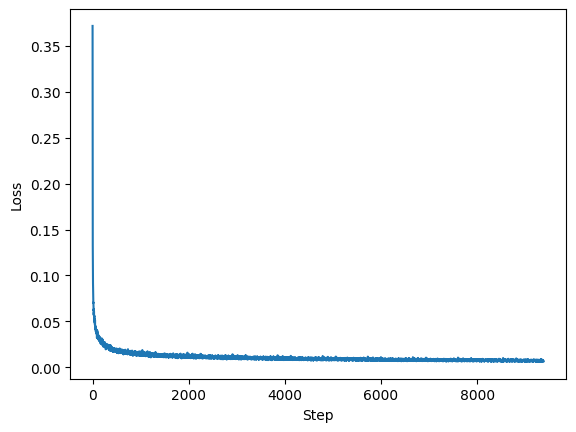

In [16]:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

In [17]:
eval_bs = 16
eval_dataloader = DataLoader(mnist["test"]["image"],batch_size=eval_bs)


model.eval()
with torch.inference_mode():
    eval_batch = next(iter(eval_dataloader))
    predicted = model(eval_batch.to(device)).cpu()

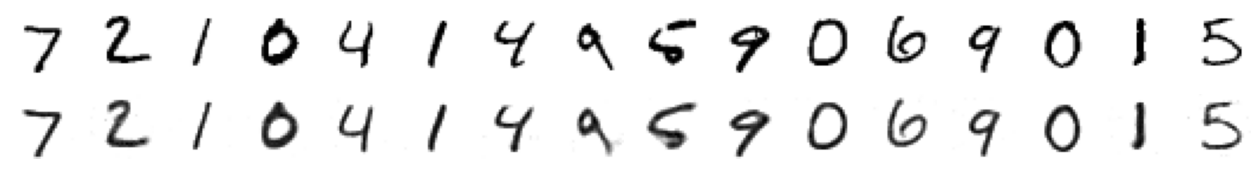

In [18]:
batch_vs_preds = torch.cat((eval_batch,predicted))
show_images(batch_vs_preds,imsize=1,nrows=2)

## Define 2 dim latent model


In [19]:
class Encoder(nn.Module):
    def __init__(self, in_channels,latent_dims):
        super().__init__()

        self.conv_layers = nn.Sequential(
            conv_block(in_channels,128),
            conv_block(128,256),
            conv_block(256,512),
            conv_block(512,1024)
        )
        self.linear = nn.Linear(1024,latent_dims)
    def forward(self,x):
        bs = x.shape[0]
        x = self.conv_layers(x)
        x = self.linear(x.reshape(bs,-1))
        return x

class Decoder(nn.Module):
    def __init__(self,out_channels,latent_dims):
        super().__init__()
        self.linear = nn.Linear(latent_dims,1024*4*4)
        self.t_conv_layers = nn.Sequential(
            conv_transpose_block(1024,512),
            conv_transpose_block(512,256,output_padding=1),
            conv_transpose_block(256,out_channels,output_padding=1,with_act=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self,x):
        bs = x.shape[0]
        x = self.linear(x)
        x = x.reshape((bs,1024,4,4))
        x = self.t_conv_layers(x)
        x = self.sigmoid(x)

        return x

In [20]:
class AutoEncoder(nn.Module):
    def __init__(self,latent_dims,in_channels):
        super().__init__()

        self.encoder = Encoder(in_channels,latent_dims)
        self.decoder = Decoder(in_channels,latent_dims)

    def encode(self,x):
        return self.encoder(x)
    
    def decode(self,x):
        return self.decoder(x)
    
    def forward(self,x):
        return self.decode(self.encode(x))

In [21]:
def train(model,num_epochs=10,lr=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(),lr=lr,eps = 1e-5)

    model.train()
    losses = []

    device = get_device()

    for _ in (progress := trange(num_epochs,desc="Training")):
        for _,batch in (
            inner := tqdm(enumerate(train_dataloader),total=len(train_dataloader))
        ):
            batch = batch.to(device)
            preds = model(batch)

            loss = F.mse_loss(preds,batch)

            inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
            losses.append(loss.item())

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        progress.set_postfix(loss=f"{loss.cpu().item():.3f}",lr=f"{lr:.0e}")
    
    
    return losses

In [22]:
ae_model = AutoEncoder(in_channels=1,latent_dims=2)

device = get_device()
ae_model.to(device)

losses = train(ae_model)

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

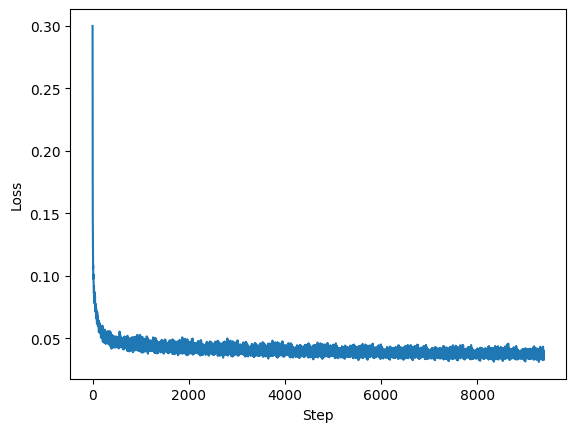

In [23]:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

In [24]:
eval_bs = 16
eval_dataloader = DataLoader(mnist["test"]["image"],batch_size=eval_bs)


ae_model.eval()
with torch.inference_mode():
    eval_batch = next(iter(eval_dataloader))
    predicted = ae_model(eval_batch.to(device)).cpu()

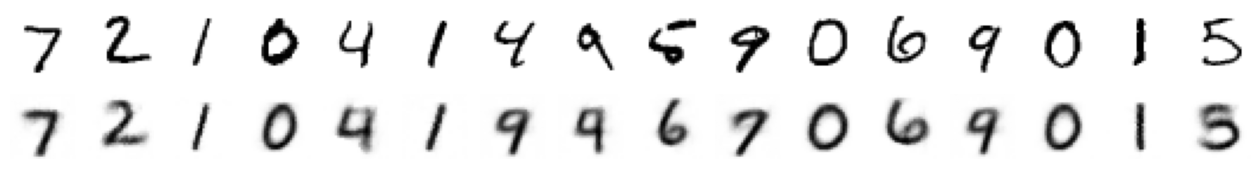

In [25]:
batch_vs_preds = torch.cat((eval_batch,predicted))
show_images(batch_vs_preds,imsize=1,nrows=2)

In [26]:

images_labels_dataloader = DataLoader(mnist["test"],batch_size=512)

import pandas as pd

df = pd.DataFrame(
    {
        "x":[],
        "y":[],
        "label":[],

    }
)



In [27]:
for batch in tqdm(
    iter(images_labels_dataloader),total=len(images_labels_dataloader)
):
    encoded = ae_model.encode(batch["image"].to(device)).cpu()
    new_items = {
        "x": [t.item() for t in encoded[:,0]],
        "y": [t.item() for t in encoded[:,1]],
        "label": batch["label"],
    }
    df = pd.concat([df,pd.DataFrame(new_items)],ignore_index = True)

  0%|          | 0/20 [00:00<?, ?it/s]

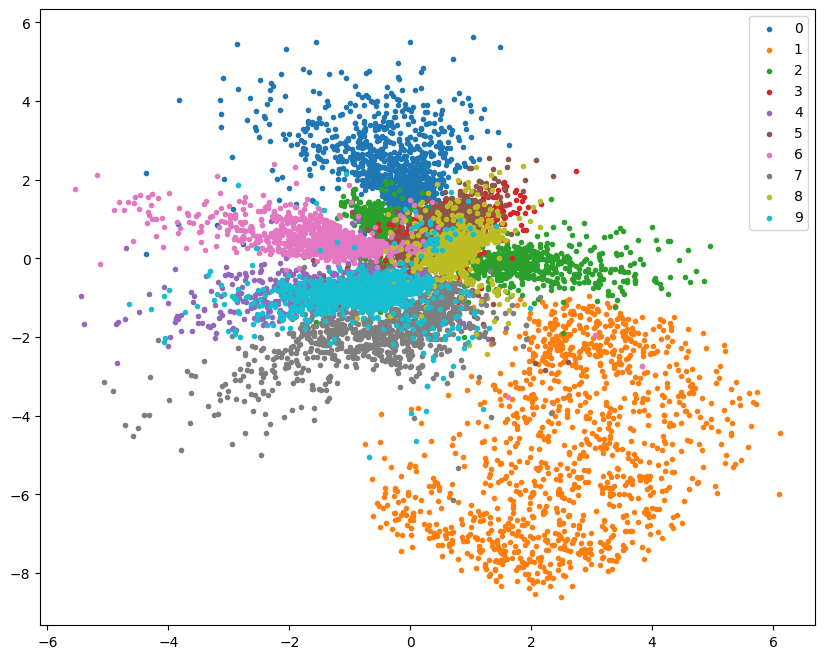

In [28]:
plt.figure(figsize=(10,8))

for label in range(10):
    points = df[df["label"] == label]
    plt.scatter(points["x"],points["y"],label = label,marker = ".")

plt.legend()
plt.show()

In [29]:
N = 16
z = torch.rand((N,2)) * 8 - 4

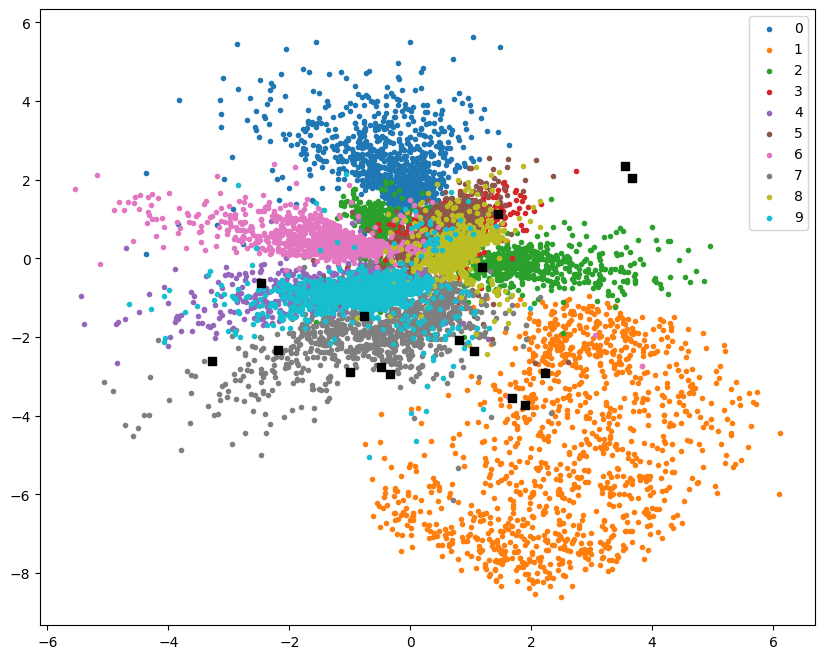

In [30]:
plt.figure(figsize = (10,8))

for label in range(10):
    points = df[df["label"] == label]
    plt.scatter(points["x"],points["y"],label = label,marker = ".")

plt.scatter(z[:,0],z[:,1],marker="s",color="black")
plt.legend()
plt.show()

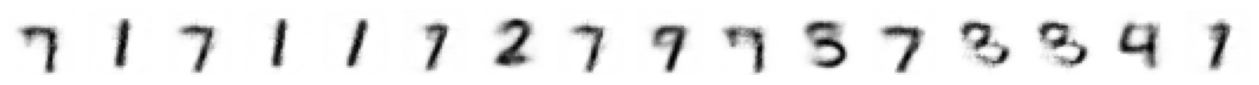

In [31]:
ae_decoded_samples = ae_model.decode(z.to(device))
show_images(ae_decoded_samples.cpu(),imsize=1,nrows=1)


## VAE

In [32]:
class VAEEncoder(nn.Module):
    def __init__(self, in_channels,latent_dims):
        super().__init__()

        self.conv_layers = nn.Sequential(
            conv_block(in_channels,128),
            conv_block(128,256),
            conv_block(256,512),
            conv_block(512,1024)
        )

        self.mu = nn.Linear(1024,latent_dims)
        self.logvar = nn.Linear(1024,latent_dims)

    def forward(self,x):
        bs = x.shape[0]
        x = self.conv_layers(x)
        x = x.reshape(bs,-1)
        mu = self.mu(x)
        logvar = self.logvar(x)

        return (mu,logvar)
    
    

In [33]:
class VAE(nn.Module):
    def __init__(self,in_channels,latent_dims):
        super().__init__()

        self.encoder = VAEEncoder(in_channels,latent_dims)
        self.decoder = Decoder(in_channels,latent_dims)

    def encode(self,x):
        return self.encoder(x)
    def decode(self,x):
        return self.decoder(x)
    
    def forward(self,x):
        mu,logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)

        z = self.sample(mu,std)
        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar
    
    def sample(self,mu,std):
        eps = torch.randn_like(std)

        return mu + eps * std

In [46]:
def vae_loss(batch,reconstructed,mu,logvar):
    bs = batch.shape[0]
    reconstruction_loss = F.mse_loss(reconstructed.reshape(bs,-1),batch.reshape(bs,-1),reduction="none").sum(dim=-1)

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2)- logvar.exp(),dim=-1)
    loss = (reconstruction_loss + kl_loss).mean(dim=0)

    return (loss,reconstruction_loss,kl_loss)

In [64]:

def train_vae(model,num_epochs = 10,lr = 1e-4):
    model = model.to(device)
    losses = {
        "loss":[],
        "recon_loss":[],
        "kl_loss":[]
    }

    model.train()
    optimizer = torch.optim.AdamW(model.parameters(),lr=lr,eps = 1e-5)

    for _ in (progress := trange(num_epochs,desc="Training")):
        for _, batch in (
            inner := tqdm(enumerate(train_dataloader),total=len(train_dataloader))
        ):
            batch = batch.to(device)

            reconstructed, mu ,logvar = model(batch)


            loss,reconstruction_loss,kl_loss = vae_loss(batch,reconstructed,mu,logvar)

            inner.set_postfix(loss=f"{loss.cpu().item():.3f}")

            losses["loss"].append(loss.item())
            losses["recon_loss"].append(reconstruction_loss.mean().item())
            losses["kl_loss"].append(kl_loss.mean().item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        progress.set_postfix(loss=f"{loss.cpu().item():.3f}",lr=f"{lr:0e}")
    return losses

In [48]:
vae_model = VAE(in_channels=1,latent_dims = 2)
losses = train_vae(vae_model,num_epochs=10,lr = 1e-4)

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

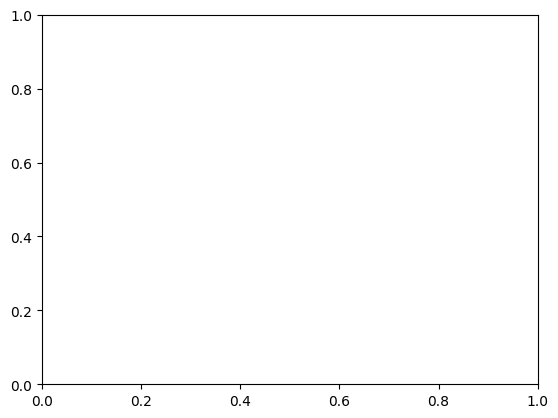

In [67]:
for k,v in losses.items():
    plt.plot(v,label=k)
plt.legend()
plt.show()

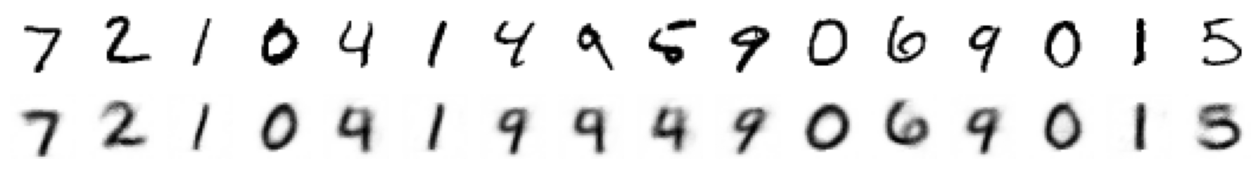

In [76]:
vae_model.eval()
with torch.inference_mode():
    eval_batch = next(iter(eval_dataloader))
    predicted,mu,logvar = (v.cpu() for v in vae_model(eval_batch.to(device)))

batch_vs_preds = torch.cat((eval_batch,predicted))
show_images(batch_vs_preds,imsize=1,nrows=2)

  0%|          | 0/20 [00:00<?, ?it/s]

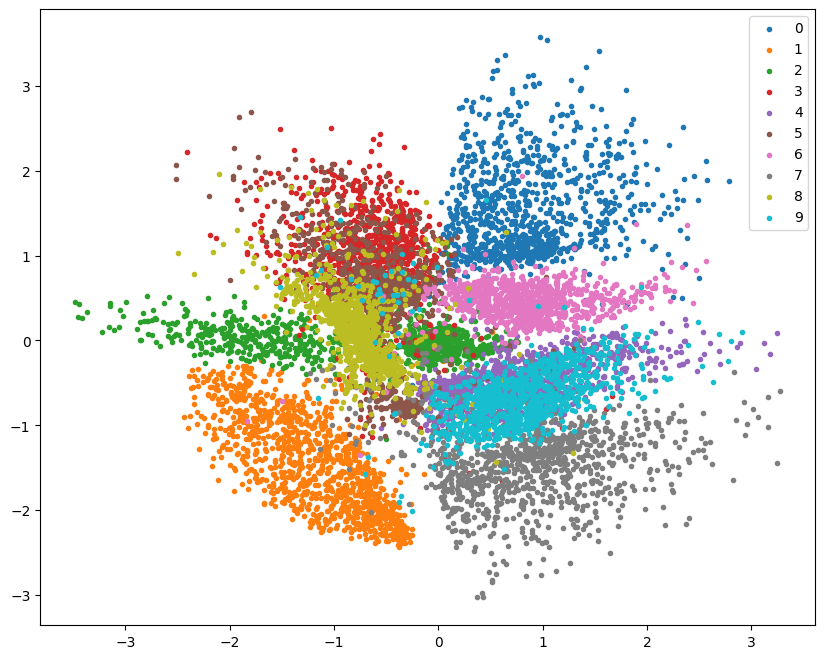

In [78]:
df = pd.DataFrame(
    {
        "x":[],
        "y":[],
        "label":[],

    }
)

for batch in tqdm(
    iter(images_labels_dataloader),total=len(images_labels_dataloader)
):
    mu, _ = vae_model.encode(batch["image"].to(device))
    mu = mu.to("cpu")
    new_items = {
        "x": [t.item() for t in mu[:,0]],
        "y": [t.item() for t in mu[:,1]],
        "label": batch["label"],
    }
    df = pd.concat([df,pd.DataFrame(new_items)],ignore_index = True)

plt.figure(figsize=(10,8))

for label in range(10):
    points = df[df["label"] == label]
    plt.scatter(points["x"],points["y"],label=label,marker = ".")

plt.legend()
plt.show()

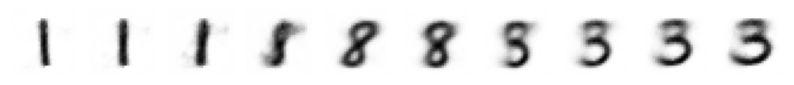

In [79]:
import numpy as np

with torch.inference_mode():
    inputs = []
    for y in np.linspace(-2,2,10):
        inputs.append([-0.8,y])
    z = torch.tensor(inputs,dtype = torch.float32).to(device)
    decoded = vae_model.decode(z)

show_images(decoded.cpu(),imsize=1 ,nrows= 1)

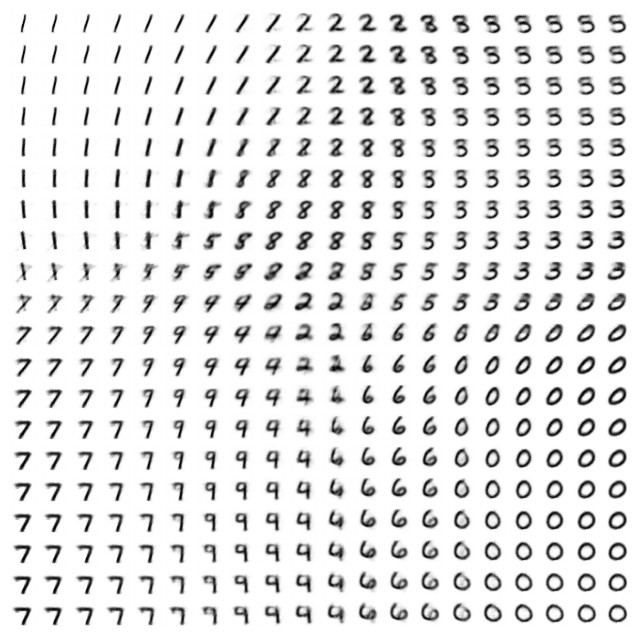

In [80]:
inputs = []

for x in np.linspace(-2,2,20):
    for y in np.linspace(-2,2,20):
        inputs.append([x,y])
z = torch.tensor(inputs,dtype=torch.float32).to(device)
decoded = vae_model.to(device).decode(z)

show_images(decoded.cpu(),imsize = 0.4,nrows=20)